<a href="https://colab.research.google.com/github/ap-ctrl/celebal_ankita/blob/main/week6_ankita_priyadarshini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Build a deep learning model that can remove noise from images using an autoencoder on MNIST**




This cell imports all the necessary libraries for building and training our autoencoder model. We'll be using `numpy` for numerical operations, `matplotlib` for plotting, and `torch` with `torch.nn`, `torch.nn.functional`, `DataLoader`, `SubsetRandomSampler`, `torch.optim` from PyTorch for deep learning. `torchvision.datasets` and `torchvision.transforms` are used to handle the MNIST dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets, transforms

Here, we define a transformation to convert our image data into PyTorch tensors. This is a crucial step as PyTorch models operate on tensor data types.

In [2]:
transform = transforms.ToTensor()

We load the MNIST dataset, separating it into training and testing sets. The `ToTensor()` transform ensures the images are converted to PyTorch tensors and normalized to a range of [0, 1].

In [3]:
train_data = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.47MB/s]


This cell simply prints the total number of images available in our training and testing datasets, giving us an overview of the dataset size.

In [4]:
print("Number of training images:", len(train_data))
print("Number of testing images:", len(test_data))

Number of training images: 60000
Number of testing images: 10000


We extract a single image and its corresponding label from the training data to inspect it. This helps in understanding the format and content of our dataset.

In [5]:
image, label = train_data[0]

print("Label:", label)

Label: 5


This cell visualizes the sample image we extracted, displaying it in grayscale and showing its corresponding digit label. This confirms that our data loading and initial processing are working correctly.

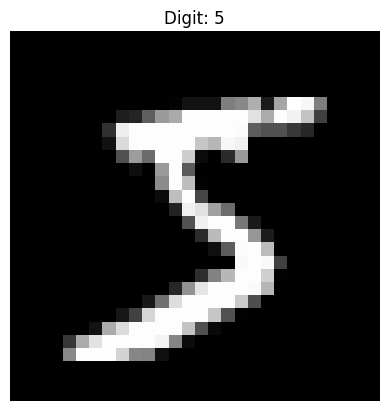

In [6]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Digit: {label}")
plt.axis("off")
plt.show()

Here, we define the `batch_size` and create `DataLoader` objects for both our training and testing datasets. DataLoaders are essential for efficiently feeding data to the model in mini-batches during training and evaluation.

In [7]:
batch_size = 20

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

We retrieve a batch of images and labels from the `train_loader` and print their shapes. This verifies that our DataLoader is correctly preparing batches of data with the expected dimensions.

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([20, 1, 28, 28])
torch.Size([20])


This is the core of our autoencoder model. We define a convolutional autoencoder architecture named `Tran_conv_Auto_MNIST` using PyTorch's `nn.Module`. It consists of an encoder to compress the image and a decoder to reconstruct it, using convolutional and transpose convolutional layers.

In [12]:
class Tran_conv_Auto_MNIST(nn.Module):

    def __init__(self):
        super(Tran_conv_Auto_MNIST, self).__init__()

        # Encoder
        self.en_conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.en_conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=4,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Decoder
        self.de_conv1 = nn.ConvTranspose2d(
            in_channels=4,
            out_channels=16,
            kernel_size=2,
            stride=2
        )

        self.de_conv2 = nn.ConvTranspose2d(
            in_channels=16,
            out_channels=1,
            kernel_size=2,
            stride=2
        )

    def forward(self, x):

        # Encoder
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))

        # Decoder
        x = F.relu(self.de_conv1(x))
        x = torch.sigmoid(self.de_conv2(x))

        return x

We instantiate our `Tran_conv_Auto_MNIST` model and print its structure. This allows us to verify the layers and their configurations within the model.

In [13]:
model = Tran_conv_Auto_MNIST()

print(model)

Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
)


We get another batch of sample images from the training loader to use for a quick check of the model's output dimensions before starting the full training process.

In [14]:
sample_images, _ = next(iter(train_loader))

print(sample_images.shape)

torch.Size([20, 1, 28, 28])


This cell passes the `sample_images` through our `model` and prints the shape of the output. This is a crucial step to ensure that the model's output shape matches the expected image dimensions (28x28 for MNIST).

In [15]:
output = model(sample_images)

print(output.shape)

torch.Size([20, 1, 28, 28])


We define the `criterion` (loss function) and the `optimizer` for our model. `MSELoss` (Mean Squared Error) is chosen because we are performing image reconstruction, and `Adam` is a popular and effective optimization algorithm.

In [16]:
# Loss Function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

This helper function, `add_noise`, introduces random Gaussian noise to the input images. The noise level is controlled by a standard deviation of 0.3, and the pixel values are clamped to ensure they remain within the valid [0, 1] range.

In [17]:
def add_noise(images):

    noise = torch.randn_like(images) * 0.3

    noisy_images = images + noise

    noisy_images = torch.clamp(noisy_images, 0., 1.)

    return noisy_images

Before training, we visualize a few original images and their noisy counterparts using the `add_noise` function. This helps us understand the level of noise our autoencoder will be tasked with removing.

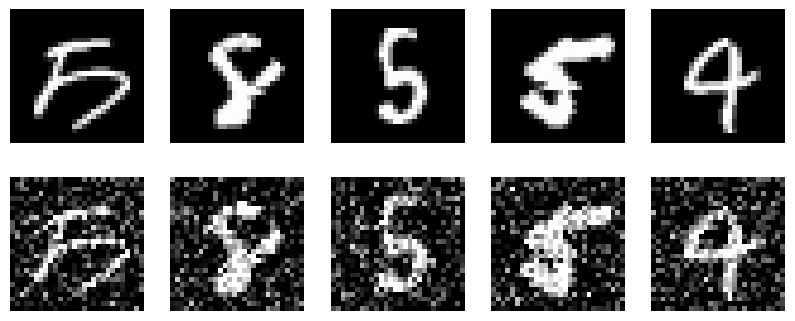

In [18]:
sample_images, _ = next(iter(train_loader))

noisy_images = add_noise(sample_images)

plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

This cell contains the main training loop for our autoencoder. It iterates for a specified number of epochs, adds noise to the training images, passes them through the model, calculates the loss, performs backpropagation, and updates the model's weights. The training loss is printed for each epoch.

In [19]:
num_epochs = 10

train_loss = []

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, _ in train_loader:

        noisy_images = add_noise(images)

        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_loss.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/10] Loss: 0.0493
Epoch [2/10] Loss: 0.0301
Epoch [3/10] Loss: 0.0268
Epoch [4/10] Loss: 0.0257
Epoch [5/10] Loss: 0.0253
Epoch [6/10] Loss: 0.0250
Epoch [7/10] Loss: 0.0248
Epoch [8/10] Loss: 0.0246
Epoch [9/10] Loss: 0.0245
Epoch [10/10] Loss: 0.0244


After training, we plot the `train_loss` over epochs. This visualization helps us monitor the training progress and see if the model is converging effectively.

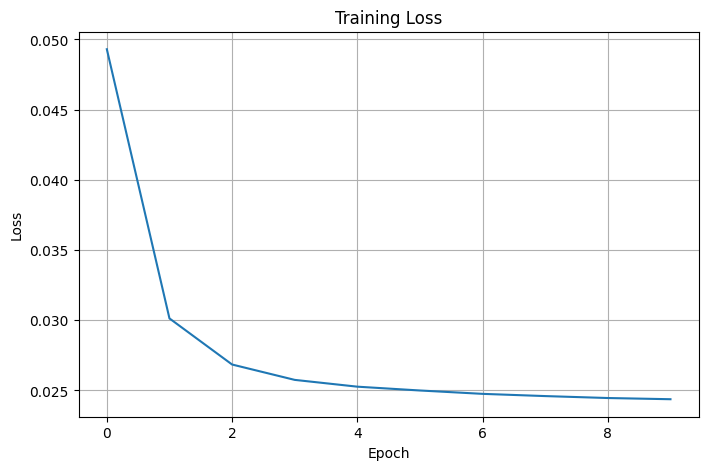

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_loss)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

This cell prepares a batch of test images by adding noise to them. It then passes these `noisy_test_images` through the trained autoencoder model in evaluation mode (`torch.no_grad()`) to obtain the `denoised_images`.

In [21]:
# Get one batch from the test dataset
test_images, _ = next(iter(test_loader))

# Add noise
noisy_test_images = add_noise(test_images)

# Turn off gradient calculation
with torch.no_grad():

    # Pass noisy images through the model
    denoised_images = model(noisy_test_images)

Finally, we visualize the results of our denoising autoencoder. This cell displays the original test images, their noisy versions, and the images reconstructed (denoised) by our model. This allows for a qualitative assessment of the autoencoder's performance.

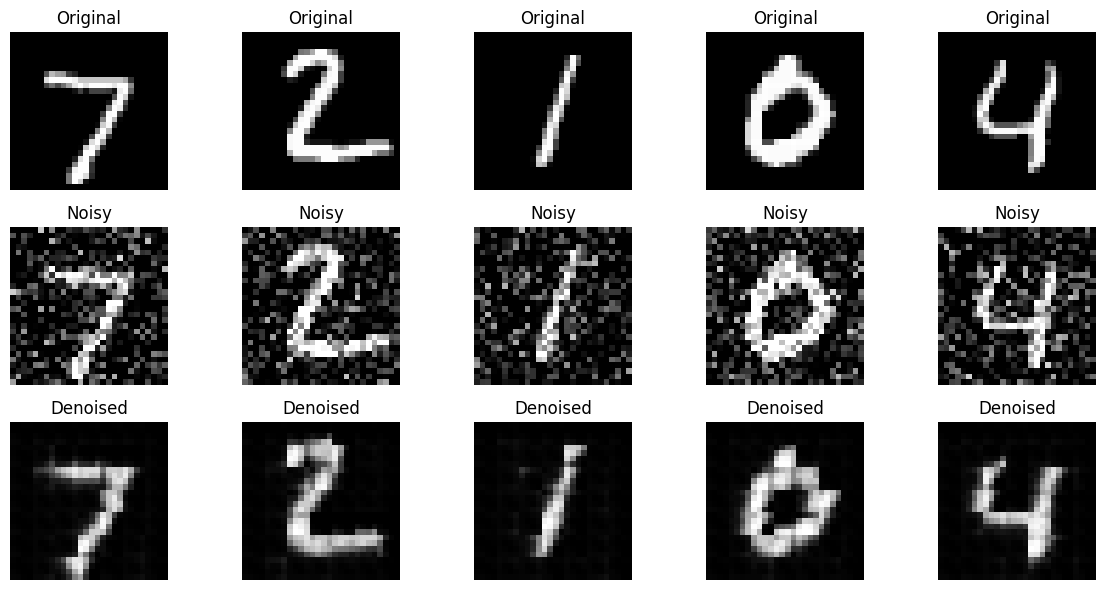

In [22]:
plt.figure(figsize=(12, 6))

for i in range(5):

    # Original Images
    plt.subplot(3, 5, i + 1)
    plt.imshow(test_images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Images
    plt.subplot(3, 5, i + 6)
    plt.imshow(noisy_test_images[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Images
    plt.subplot(3, 5, i + 11)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

This cell saves the trained model's state dictionary to a file named `mnist_autoencoder.pth`. Saving the model allows us to load and reuse it later without needing to retrain it.

In [23]:
torch.save(model.state_dict(), "mnist_autoencoder.pth")

print("Model saved successfully!")

Model saved successfully!


## Conclusion

In this project, we successfully built and trained a convolutional autoencoder to denoise images from the MNIST dataset. We demonstrated the full pipeline, from data loading and preparation to model definition, training, and evaluation.

The autoencoder effectively learned to reconstruct original images from their noisy counterparts, showcasing its ability to remove Gaussian noise. The training loss decreased steadily, indicating good model convergence, and the visualizations confirmed the model's performance in restoring the digits.

This project serves as a foundational example of using deep learning for image denoising, a task with broad applications in image processing and computer vision.